In [2]:
import torch
import cv2
import numpy as np
from torchvision import transforms
from PIL import Image

In [10]:
import torch
import torch.nn as nn

class DocumentCornerModel(nn.Module):
    def __init__(self):
        super(DocumentCornerModel, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x


In [20]:
# Load model with the weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DocumentCornerModel().to(device)
model.load_state_dict(torch.load("dl_project_doc_extract_weights.pt", map_location=device))
model.eval()

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load and preprocess input image
image_path = "smart_doc_extracted/images/background01-tax002-7.png"  
original_image = Image.open(image_path).convert("RGB")
input_tensor = transform(original_image).unsqueeze(0).to(device)


In [21]:
# Get prediction
with torch.no_grad():
    output = model(input_tensor).cpu().numpy().flatten()

# Map output to corners
pred_coords = np.array([
    output[2], output[6],  # top-left (x, y)
    output[3], output[7],  # top-right
    output[1], output[5],  # bottom-right
    output[0], output[4]   # bottom-left
], dtype=np.float32).reshape(4, 2)

# Load original image for warping
orig_np = np.array(original_image)
if orig_np.shape[2] == 1:
    orig_np = cv2.cvtColor(orig_np, cv2.COLOR_GRAY2BGR)


In [22]:
# predicted corner points
width_top = np.linalg.norm(pred_coords[0] - pred_coords[1])
width_bottom = np.linalg.norm(pred_coords[2] - pred_coords[3])
height_left = np.linalg.norm(pred_coords[0] - pred_coords[3])
height_right = np.linalg.norm(pred_coords[1] - pred_coords[2])
width = int(max(width_top, width_bottom))
height = int(max(height_left, height_right))

dst_pts = np.array([
    [0, 0],
    [width - 1, 0],
    [width - 1, height - 1],
    [0, height - 1]
], dtype=np.float32)


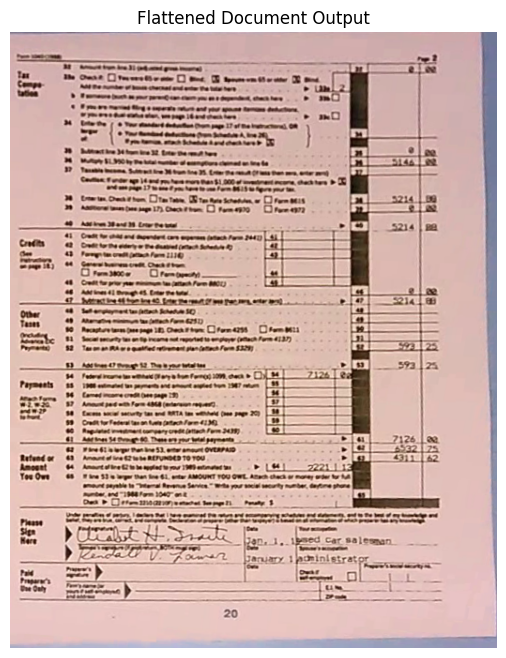

Saved: flattened_output.png


In [23]:
import matplotlib.pyplot as plt

M = cv2.getPerspectiveTransform(pred_coords, dst_pts)
warped = cv2.warpPerspective(orig_np, M, (width, height))

warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10, 8))
plt.imshow(warped_rgb)
plt.title("Flattened Document Output")
plt.axis("off")
plt.show()

# Save result
cv2.imwrite("flattened_output.png", warped)
print("Saved: flattened_output.png")


In [37]:
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

In [38]:
class Unet(nn.Module):
  def __init__(self):
    super().__init__()

    def convblock(in_ch, out_ch):
      return nn.Sequential(
          nn.Conv2d(in_ch, out_ch, 3, padding = 1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace = True),
          nn.Conv2d(out_ch, out_ch, 3, padding = 1),
          nn.BatchNorm2d(out_ch),
          nn.ReLU(inplace = True),
      )

    self.enc1 = convblock(1, 64)
    self.enc2 = convblock(64, 128)
    self.enc3 = convblock(128, 256)

    self.pool = nn.MaxPool2d(2)

    self.middle = convblock(256, 512)

    self.up3 = nn.ConvTranspose2d(512, 256, 2, stride = 2)
    self.dec3 = convblock(512, 256)

    self.up2 = nn.ConvTranspose2d(256, 128, 2, stride = 2)
    self.dec2 = convblock(256, 128)
    self.up1 = nn.ConvTranspose2d(128, 64, 2, stride = 2)
    self.dec1 = convblock(128, 64)

    self.out = nn.Conv2d(64, 1, 1)

  def forward(self, x):
    e1 = self.enc1(x)
    e2 = self.enc2(self.pool(e1))
    e3 = self.enc3(self.pool(e2))

    m = self.middle(self.pool(e3))

    d3 = self.dec3(torch.cat((self.up3(m), e3), dim = 1))
    d2 = self.dec2(torch.cat((self.up2(d3), e2), dim = 1))
    d1 = self.dec1(torch.cat((self.up1(d2), e1), dim = 1))

    return torch.sigmoid(self.out(d1))

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Unet().to(device)
model.load_state_dict(torch.load("/Users/visheshbhargava/Desktop/model.pt", map_location=device))
model.eval()

Unet(
  (enc1): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (enc3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_r

In [52]:
input_path = "/Users/visheshbhargava/Desktop/flattened_output.png"
img = Image.open(input_path).convert("L")
original_size = img.size

In [53]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

input_tensor = transform(img).unsqueeze(0).to(device)


In [54]:
with torch.no_grad():
    output = model(input_tensor).squeeze(0).cpu()

output_np = (output.squeeze().numpy() * 255).astype(np.uint8)
enhanced_img = Image.fromarray(output_np).resize(original_size)
enhanced_img.save("enhanced_output.png")
print("Saved: enhanced_output.png")

Saved: enhanced_output.png


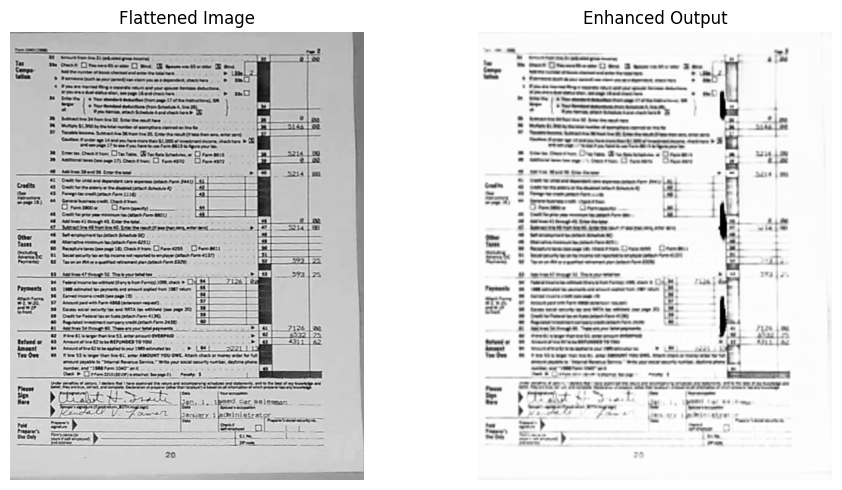

In [55]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Flattened Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced_img, cmap="gray")
plt.title("Enhanced Output")
plt.axis("off")
plt.tight_layout()
plt.show()